### ==============================================================================
## Processing of Moving Vessel Profiler Data - code 0.2
### Authors: Elisabet Verger-Miralles (everger@imedea.uib-csic.es) & Bàrbara Barceló-Llull (bbarcelo@imedea.uib-csic.es)
### Data from BioSWOT experiment
# 
**DESCRIPTION**:
 This script performs the first quality control and profile selection on the 
 raw NetCDF files generated in step 0.1. It filters profiles based on specific 
 criteria such as minimum maximum depth, maximum starting depth, minimum number 
 of data points, and maximum allowed fraction of NaNs. It generates CSV logs 
 for both selected and rejected profiles, detailing the reasons for rejection.
#
 INPUT: Directory containing raw *_downcast.nc files.
#
 OUTPUT: CSV files listing selected and rejected profiles, and optionally 
 a folder with the physically copied selected NetCDF files.
### ==============================================================================

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import shutil

# ==========================
# USER SETTINGS (BIOSWOT)
# ==========================
# Input directory containing raw NetCDF files (output from step 0.1)
dir_nc = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_bioswot_nc_final_processing\raw") 

# Output directory for the selection results
dir_output = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_bioswot_nc_final_processing\selected_profiles")

# Search pattern: Important to use *_downcast.nc if the previous split script was used
# If your files are just named .nc, change this to "*.nc"
pattern = "*_downcast.nc" 

# Selection Criteria (Adjustable)
MIN_ZMAX = 80.0      # Minimum required maximum depth
MAX_ZMIN = 10.0      # Maximum starting depth (profile must start before 10m)
MIN_NPTS = 30        # Minimum number of data points required
MAX_NAN_FRAC = 0.2   # Maximum allowed fraction of NaNs per variable

# Output files
dir_output.mkdir(parents=True, exist_ok=True)
out_csv = dir_output / "selected_profiles.csv"
out_rej = dir_output / "rejected_profiles.csv"

# Option to physically copy the selected files to another folder
copy_selected = False
dir_sel = dir_output / "selected_nc"
if copy_selected:
    dir_sel.mkdir(exist_ok=True)

# ==========================
# PROCESS
# ==========================
rows = []
rej_rows = []

# Verify if the input directory exists
if not dir_nc.exists():
    print(f"❌ ERROR: Cannot find input directory: {dir_nc}")
    print("   Make sure Step 0.1 saved the files there.")
else:
    files = sorted(dir_nc.glob(pattern))
    print(f"Found {len(files)} netCDF files in {dir_nc}")

    count = 0
    for f in files:
        try:
            ds = xr.open_dataset(f)

            # --- READ VARIABLES ---
            # Pressure
            if "pressure" in ds: depth = ds["pressure"].values
            elif "Depth" in ds: depth = ds["Depth"].values
            elif "Press" in ds: depth = ds["Press"].values
            else: raise ValueError("Variable pressure/Depth not found")

            # Temperature
            if "t1" in ds: temp = ds["t1"].values
            elif "Temp" in ds: temp = ds["Temp"].values
            else: temp = np.full_like(depth, np.nan)

            # Conductivity
            if "c1" in ds: cond = ds["c1"].values
            elif "Cond" in ds: cond = ds["Cond"].values
            else: cond = np.full_like(depth, np.nan)

            # Salinity (Solo para control de calidad)
            if "s_raw" in ds: sal = ds["s_raw"].values
            elif "Sal" in ds: sal = ds["Sal"].values
            else: sal = np.full_like(depth, np.nan)

            # --- STATISTICAL CALCULATIONS ---
            if len(depth) > 0:
                zmax = np.nanmax(depth)
                zmin = np.nanmin(depth)
                npts = np.isfinite(depth).sum()
            else:
                zmax, zmin, npts = 0.0, 0.0, 0

            nanT = np.mean(~np.isfinite(temp)) if len(temp) > 0 else 1.0
            nanC = np.mean(~np.isfinite(cond)) if len(cond) > 0 else 1.0
            nanS = np.mean(~np.isfinite(sal)) if len(sal) > 0 else 1.0

            # --- REJECTION CRITERIA CHECK ---
            reasons = []
            if not (zmax >= MIN_ZMAX): reasons.append(f"zmax({zmax:.1f})<{MIN_ZMAX}")
            if not (zmin <= MAX_ZMIN): reasons.append(f"zmin({zmin:.1f})>{MAX_ZMIN}")
            if not (npts >= MIN_NPTS): reasons.append(f"npts({npts})<{MIN_NPTS}")
            if nanT > MAX_NAN_FRAC: reasons.append(f"nanT({nanT:.2f})>{MAX_NAN_FRAC}")
            if nanC > MAX_NAN_FRAC: reasons.append(f"nanC({nanC:.2f})>{MAX_NAN_FRAC}")
            
            row = dict(
                file=f.name,
                stem=f.stem,
                zmin=float(zmin),
                zmax=float(zmax),
                npts=int(npts),
                nanT=float(nanT),
                nanC=float(nanC),
                nanS=float(nanS),
            )

            if len(reasons) == 0:
                rows.append(row)
                if copy_selected:
                    shutil.copy2(f, dir_sel / f.name)
            else:
                row["reasons"] = ";".join(reasons)
                rej_rows.append(row)

            ds.close()
            
            count += 1
            if count % 100 == 0: print(f" ... {count} checked")

        except Exception as e:
            rej_rows.append(dict(file=f.name, stem=f.stem, reasons=f"read_error: {str(e)}"))

    # --- SAVE RESULTS ---
    if len(rows) > 0:
        df_sel = pd.DataFrame(rows).sort_values(["zmax"], ascending=False)
        df_sel.to_csv(out_csv, index=False)
        print(f"\n✅ Selected profiles: {len(df_sel)}")
        print(f"   CSV saved to: {out_csv}")
    else:
        print("\n⚠️ WARNING: No profiles selected! (rows list is empty)")

    if len(rej_rows) > 0:
        df_rej = pd.DataFrame(rej_rows)
        df_rej.to_csv(out_rej, index=False)
        print(f"❌ Rejected profiles: {len(df_rej)}")
        print(f"   CSV saved to: {out_rej}")
    else:
        # Create empty CSV to avoid errors if no profiles were rejected
        pd.DataFrame(columns=['file', 'reasons']).to_csv(out_rej, index=False)

c:\Users\ASUS\anaconda3\envs\env_elisabet\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Found 640 netCDF files in C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_bioswot_nc_final_processing\raw
 ... 100 checked
 ... 200 checked
 ... 300 checked
 ... 400 checked
 ... 500 checked
 ... 600 checked

✅ Selected profiles: 633
   CSV saved to: C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_bioswot_nc_final_processing\selected_profiles\selected_profiles.csv
❌ Rejected profiles: 7
   CSV saved to: C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_bioswot_nc_final_processing\selected_profiles\rejected_profiles.csv


Plotting 633 profiles from selected_profiles.csv...
 ... painted 100
 ... painted 200
 ... painted 300
 ... painted 400
 ... painted 500
 ... painted 600


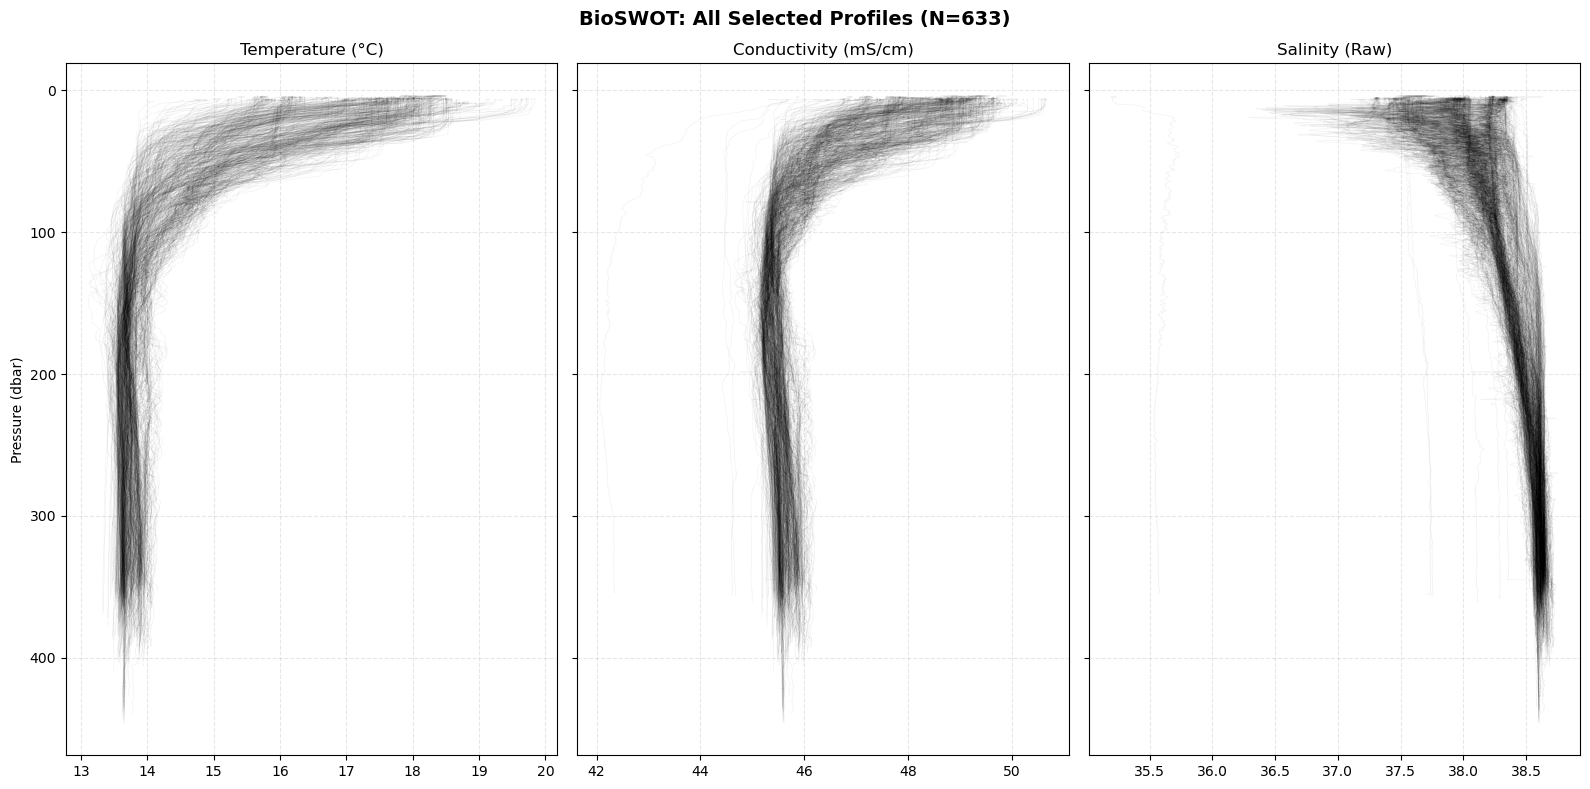

✅ Figura guardada en: C:\Users\ASUS\Desktop\MVP\MVP_bioswot_nc_final_processing\DIAG_SELECTION\BioSWOT_All_Selected_Profiles.png


In [ ]:
# import matplotlib.pyplot as plt
# import xarray as xr
# import pandas as pd
# from pathlib import Path
# import numpy as np

# # ==========================
# # CONFIGURACIÓN
# # ==========================
# # Ruta base de BioSWOT (Ajusta si es necesario)
# BASE_DIR = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_bioswot_nc_final_processing")

# # Archivo con la lista de seleccionados (Salida del Paso 0.2)
# CSV_PATH = BASE_DIR / "selected_profiles" / "selected_profiles.csv"

# # Carpeta donde están los netCDF reales
# NC_DIR = BASE_DIR / "raw_step0"

# # Carpeta para guardar la figura
# OUT_FIG = BASE_DIR / "DIAG_SELECTION"
# OUT_FIG.mkdir(exist_ok=True)

# # ==========================
# # PLOT
# # ==========================
# # Cargar lista de archivos
# if not CSV_PATH.exists():
#     print(f"❌ No encuentro el CSV: {CSV_PATH}")
# else:
#     df = pd.read_csv(CSV_PATH)
#     print(f"Plotting {len(df)} profiles from {CSV_PATH.name}...")

#     # Crear figura de 3 paneles
#     fig, axs = plt.subplots(1, 3, figsize=(16, 8), sharey=True)
    
#     # Configurar títulos
#     axs[0].set_title("Temperature (°C)")
#     axs[1].set_title("Conductivity (mS/cm)")
#     axs[2].set_title("Salinity (Raw)")
#     axs[0].set_ylabel("Pressure (dbar)")

#     # Bucle para pintar cada perfil
#     count = 0
#     for idx, row in df.iterrows():
#         file_name = row['file']
#         file_path = NC_DIR / file_name
        
#         try:
#             with xr.open_dataset(file_path) as ds:
#                 # Recuperar variables (con nombres estándar del paso 0.1)
#                 p = ds['pressure'].values if 'pressure' in ds else ds['Pressure'].values
                
#                 # Temperatura
#                 if 't1' in ds: t = ds['t1'].values
#                 elif 'Temp' in ds: t = ds['Temp'].values
#                 else: t = np.nan
                
#                 # Conductividad
#                 if 'c1' in ds: c = ds['c1'].values
#                 elif 'Cond' in ds: c = ds['Cond'].values
#                 else: c = np.nan
                
#                 # Salinidad (Raw)
#                 if 's_raw' in ds: s = ds['s_raw'].values
#                 elif 'Sal' in ds: s = ds['Sal'].values
#                 else: s = np.nan

#                 # Plot (usamos alpha bajo para ver densidad)
#                 axs[0].plot(t, p, color='k', alpha=0.05, lw=0.5)
#                 axs[1].plot(c, p, color='k', alpha=0.05, lw=0.5)
#                 axs[2].plot(s, p, color='k', alpha=0.05, lw=0.5)
                
#                 count += 1
#                 if count % 100 == 0: print(f" ... painted {count}")

#         except Exception as e:
#             print(f"Error reading {file_name}: {e}")

#     # Ajustes finales de estilo
#     for ax in axs:
#         ax.invert_yaxis()
#         ax.grid(True, alpha=0.3, linestyle='--')
#         # ax.set_ylim(250, 0) # Descomenta si quieres forzar zoom a 250m
    
#     plt.suptitle(f"BioSWOT: All Selected Profiles (N={count})", fontsize=14, fontweight='bold')
#     plt.tight_layout()
    
#     # Guardar
#     save_path = OUT_FIG / "BioSWOT_All_Selected_Profiles.png"
#     plt.savefig(save_path, dpi=150)
#     plt.show()
    
#     print(f"✅ Figura guardada en: {save_path}")